In [12]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import os

# Install wandb
!pip install wandb -q
import wandb
from kaggle_secrets import UserSecretsClient

# Input data
dataset_path = ""
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        path = os.path.join(dirname, filename)
        if "Smartphone_Usage_Productivity_Dataset_50000.csv" in filename:
            dataset_path = path

if not dataset_path:
    dataset_path = 'Smartphone_Usage_Productivity_Dataset_50000.csv'

In [15]:
import numpy as np
import pandas as pd
import torch
import sklearn
import tqdm

print(f"Numpy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"Weights and Bias version: {wandb.__version__}")
print(f"Tqdm version: {tqdm.__version__}")

Numpy version: 2.0.2
Pandas version: 2.3.3
PyTorch version: 2.9.0+cu126
Scikit-learn version: 1.6.1
Weights and Bias version: 0.24.0
Tqdm version: 4.67.1


uncomment the following line to install dependencies with their specific versions

In [ ]:
# %pip install numpy==2.0.2 pandas==2.3.3 torch==2.9.0 scikit-learn==1.6.1 wandb==0.24.0 tqdm==4.67.1

# 1. Data Loading, Preprocessing & Splitting

[Kaggle Dataset Link](https://www.kaggle.com/datasets/amar5693/screen-time-sleep-and-stress-analysis-dataset)

We split the data into **Train (70%)**, **Validation (15%)**, and **Test (15%)**.

In [2]:
# Load
df = pd.read_csv(dataset_path)
if 'User_ID' in df.columns: df = df.drop(columns=['User_ID'])

# Preprocess
categorical_cols = ['Gender', 'Occupation', 'Device_Type']
target_col = 'Work_Productivity_Score'
df_processed = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df_processed.drop(columns=[target_col]).values
y = df_processed[target_col].values.astype(float)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

# --- SPLITTING DATA (Train: 70%, Val: 15%, Test: 15%) ---
# First split: 70% Train, 30% Temp (Val + Test)
X_train, X_temp, y_train, y_temp = train_test_split(X_tensor, y_tensor, test_size=0.30, random_state=42)

# Second split: Split the 30% Temp into equal halves (15% Val, 15% Test)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

# DataLoaders
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=64, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=64, shuffle=False)

print(f"Train Shape: {X_train.shape}")
print(f"Val Shape:   {X_val.shape}")
print(f"Test Shape:  {X_test.shape}")

input_dim = X_tensor.shape[1]
criterion = nn.MSELoss()

Train Shape: torch.Size([35000, 14])
Val Shape:   torch.Size([7500, 14])
Test Shape:  torch.Size([7500, 14])


# 2. WandB Setup & Helper Functions
We initialize WandB to track all 4 models in a single experiment table.

In [3]:
try:
    user_secrets = UserSecretsClient()
    wandb_api_key = user_secrets.get_secret("WANDB")
    wandb.login(key=wandb_api_key)
except:
    print("Manual login required or key not found.")
    wandb.login()

# Initialize Run
run = wandb.init(
    project="productivity-prediction",
    name="4_Model_Comparison_Split",
    config={"dataset": "Smartphone_Usage_Productivity"}
)

# Global list to store results for final comparison
comparison_results = []

def evaluate(model, X_data, y_data):
    model.eval()
    with torch.no_grad():
        preds = model(X_data)
        loss = criterion(preds, y_data)
    return loss.item()

def log_model_result(name, train_loss, val_loss, test_loss, description):
    comparison_results.append([name, train_loss, val_loss, test_loss, description])
    # Also log as a metric for this step
    wandb.log({
        f"{name}_Train_Loss": train_loss,
        f"{name}_Val_Loss": val_loss,
        f"{name}_Test_Loss": test_loss
    })
    print(f"\n--- {name} Results ---")
    print(f"Train Loss: {train_loss:.6f}")
    print(f"Val Loss:   {val_loss:.6f}")
    print(f"Test Loss:  {test_loss:.6f}")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: omarelgammal2004 (omarelgammal) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


# 3. Model 1: Single Sample Training
Overfit completely on 1 sample.  
Expectation: 0 loss on the sample, high test error which is underfitting because it barely saw the data

In [4]:
# 1. Prepare Data (One Sample)
X_single = X_train[0:1]
y_single = y_train[0:1]

# 2. Define Model
model_1 = nn.Sequential(nn.Linear(input_dim, 1))
optimizer_1 = optim.Adam(model_1.parameters(), lr=0.1)

# 3. Train
print("Training Model 1 (1 Sample)...")
for _ in range(200):
    optimizer_1.zero_grad()
    loss = criterion(model_1(X_single), y_single)
    loss.backward()
    optimizer_1.step()

# 4. Evaluate
# NOTE: For this specific model, "Train Loss" is calculated on the data it saw (the single sample)
loss_train = evaluate(model_1, X_single, y_single) 
loss_val = evaluate(model_1, X_val, y_val)
loss_test = evaluate(model_1, X_test, y_test)

log_model_result("Model_1_OneSample", loss_train, loss_val, loss_test, "Overfit on 1 Sample")

Training Model 1 (1 Sample)...

--- Model_1_OneSample Results ---
Train Loss: 0.000000
Val Loss:   36.320892
Test Loss:  35.568085


# 4. Model 2: 5 Samples Training
Overfit the simple model on 5 samples  
Expectation: loss on the 5 samples would be almost 0, high test loss but might be better than the 1 sample test loss

In [5]:
# 1. Prepare Data (5 Samples)
indices = torch.arange(5)
X_five = X_train[indices]
y_five = y_train[indices]

# 2. Define Model
model_2 = nn.Sequential(nn.Linear(input_dim, 1))
optimizer_2 = optim.Adam(model_2.parameters(), lr=0.05)

# 3. Train
print("Training Model 2 (5 Samples)...")
for _ in range(500):
    optimizer_2.zero_grad()
    loss = criterion(model_2(X_five), y_five)
    loss.backward()
    optimizer_2.step()

# 4. Evaluate
loss_train = evaluate(model_2, X_five, y_five) # Loss on the 5 samples it saw
loss_val = evaluate(model_2, X_val, y_val)
loss_test = evaluate(model_2, X_test, y_test)

log_model_result("Model_2_FiveSamples", loss_train, loss_val, loss_test, "Overfit on 5 Samples")

Training Model 2 (5 Samples)...

--- Model_2_FiveSamples Results ---
Train Loss: 0.000000
Val Loss:   40.582397
Test Loss:  40.596226


# 5. Model 3: Complex Model (Overfit Whole Data)

Use a complex network on the full training set without regularization.  
Expectation: low training loss, higher test loss which is overfitting on the test data  
the dataset is relatively large with 50k samples, so it might need a large number of epochs to overfit

In [ ]:
# 1. Define Complex Model (No Dropout)
class ComplexOverfit(nn.Module):
    def __init__(self, input_dim):
        super(ComplexOverfit, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x): return self.net(x)

model_3 = ComplexOverfit(input_dim)
optimizer_3 = optim.Adam(model_3.parameters(), lr=0.001)

# 2. Train
print("Training Model 3 (Complex Overfit)...")
for epoch in tqdm(range(100)):
    for bx, by in train_loader:
        optimizer_3.zero_grad()
        loss = criterion(model_3(bx), by)
        loss.backward()
        optimizer_3.step()

# 3. Evaluate
loss_train = evaluate(model_3, X_train, y_train)
loss_val = evaluate(model_3, X_val, y_val)
loss_test = evaluate(model_3, X_test, y_test)

log_model_result("Model_3_ComplexOverfit", loss_train, loss_val, loss_test, "Complex/No Reg (Overfitting)")

Training Model 3 (Complex Overfit)...


100%|██████████| 100/100 [02:21<00:00,  1.41s/it]


--- Model_3_ComplexOverfit Results ---
Train Loss: 5.364398
Val Loss:   11.122237
Test Loss:  10.919439


# 6. Model 4: Complex Model + Regularization (Target Best)
Using l1, l2, and dropout to generalize well and regularize the complex model.  
Expectation: train loss slightly higher than the complex model but test loss should be the best as it would be the best generalization

In [7]:
# 1. Define Regularized Model
class ComplexRegularized(nn.Module):
    def __init__(self, input_dim):
        super(ComplexRegularized, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.4), # Dropout
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.4), # Dropout
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x): return self.net(x)

def l1_loss(model, l1_lambda):
    l1 = sum(p.abs().sum() for p in model.parameters())
    return l1_lambda * l1

model_4 = ComplexRegularized(input_dim)
# L2 is weight_decay
optimizer_4 = optim.Adam(model_4.parameters(), lr=0.001, weight_decay=1e-4)

# 2. Train
print("Training Model 4 (Regularized)...")
for epoch in tqdm(range(15)):
    for bx, by in train_loader:
        optimizer_4.zero_grad()
        outputs = model_4(bx)
        
        # MSE + L1
        loss = criterion(outputs, by) + l1_loss(model_4, 1e-5)
        
        loss.backward()
        optimizer_4.step()

# 3. Evaluate
loss_train = evaluate(model_4, X_train, y_train)
loss_val = evaluate(model_4, X_val, y_val)
loss_test = evaluate(model_4, X_test, y_test)

log_model_result("Model_4_Regularized", loss_train, loss_val, loss_test, "Regularized (Target Best)")

# Save this best model
torch.save(model_4.state_dict(), "best_model_regularized.pth")

Training Model 4 (Regularized)...


100%|██████████| 15/15 [00:29<00:00,  1.99s/it]


--- Model_4_Regularized Results ---
Train Loss: 8.233789
Val Loss:   8.459459
Test Loss:  8.188794


# 7. Final Comparison & WandB Logging

In [8]:
# Create DataFrame for better visualization
columns = ["Model", "Train Loss (Specific)", "Val Loss", "Test Loss", "Description"]
wandb_table = wandb.Table(data=comparison_results, columns=columns)

wandb.log({"Final Comparison Table": wandb_table})

# Log Bar Chart for Test Loss Comparison
data_for_plot = [[r[0], r[3]] for r in comparison_results]
plot_table = wandb.Table(data=data_for_plot, columns=["Model", "Test Loss (MSE)"])
wandb.log({
    "Test Loss Comparison": wandb.plot.bar(
        plot_table, "Model", "Test Loss (MSE)", title="Final Test Performance"
    )
})

print("Experiment Complete. Check WandB Dashboard.")
wandb.finish()

Experiment Complete. Check WandB Dashboard.


Model_1_OneSample_Test_Loss,▁
Model_1_OneSample_Train_Loss,▁
Model_1_OneSample_Val_Loss,▁
Model_2_FiveSamples_Test_Loss,▁
Model_2_FiveSamples_Train_Loss,▁
Model_2_FiveSamples_Val_Loss,▁
Model_3_ComplexOverfit_Test_Loss,▁
Model_3_ComplexOverfit_Train_Loss,▁
Model_3_ComplexOverfit_Val_Loss,▁
Model_4_Regularized_Test_Loss,▁
+2,...


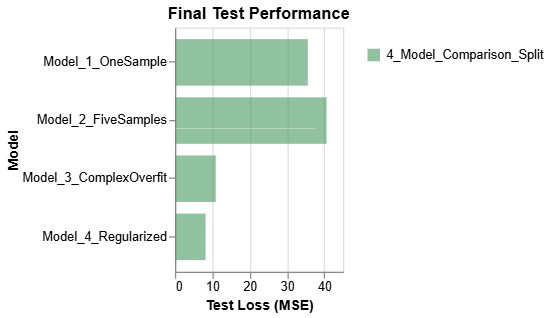

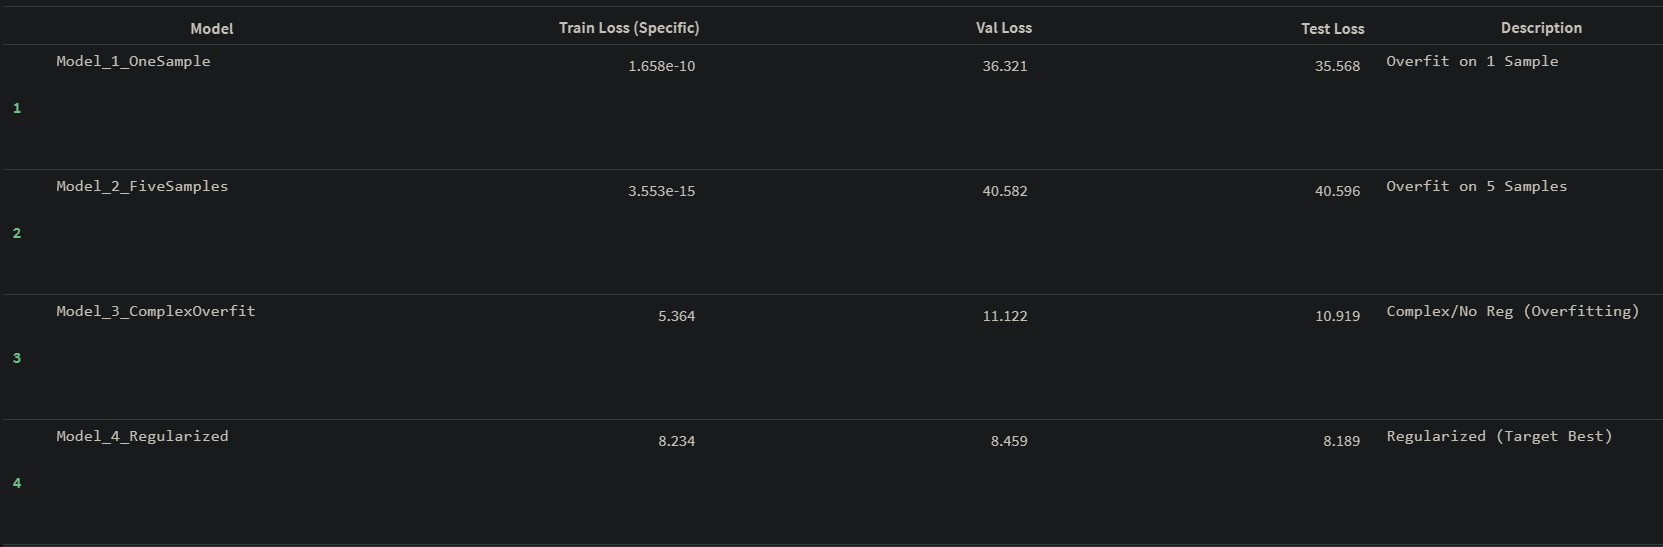

**Insights:**
- all the models performed as expected
- except the five sample model performed worse than the 1 sample model  
- might be due to a better weight initialization in the first model
